# 03 — K-Means & Hierarchical Clustering
Find the optimal number of customer segments (K) using the Elbow
Method and Silhouette Analysis, then compare against Hierarchical
Clustering with a dendrogram.

In [1]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from scipy.cluster.hierarchy import dendrogram, linkage

from src.preprocessing import get_feature_matrix, FEATURE_COLUMNS
from src.clustering import elbow_and_silhouette, fit_kmeans, fit_hierarchical, label_personas

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [2]:
df = pd.read_csv("../data/processed/mall_customers_clean.csv")
scaler = joblib.load("../models/scaler.joblib")

X = get_feature_matrix(df)
X_scaled = scaler.transform(X)

## Elbow Method + Silhouette Analysis

In [3]:
metrics_df = elbow_and_silhouette(X_scaled, k_range=range(2, 11))
metrics_df

,k,inertia,silhouette
0,2,442.481328,0.334624
1,3,336.532965,0.336668
2,4,238.379567,0.397688
3,5,194.686042,0.374507
4,6,172.245006,0.384256
5,7,148.785901,0.398260
6,8,130.584529,0.368988
7,9,114.089128,0.379202
8,10,101.985505,0.364000


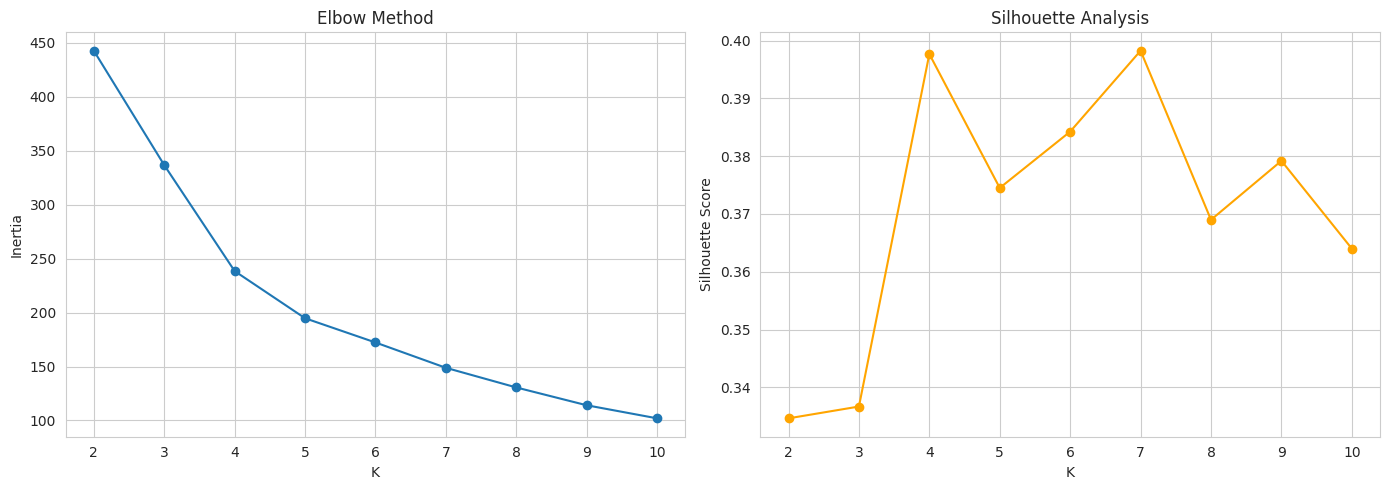

K with highest silhouette score: 7


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(metrics_df["k"], metrics_df["inertia"], marker="o")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow Method")

axes[1].plot(metrics_df["k"], metrics_df["silhouette"], marker="o", color="orange")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Analysis")

plt.tight_layout()
plt.savefig("../reports/figures/03_elbow_silhouette.png", dpi=120)
plt.show()

best_k = int(metrics_df.loc[metrics_df["silhouette"].idxmax(), "k"])
print(f"K with highest silhouette score: {best_k}")

## Fit final K-Means model
Using the K chosen above (edit `chosen_k` if you disagree with the
automatic pick after looking at the elbow plot).

In [5]:
chosen_k = best_k  # override manually here if the elbow plot suggests otherwise, e.g. chosen_k = 5

kmeans_model, kmeans_labels = fit_kmeans(X_scaled, n_clusters=chosen_k)
df["Cluster"] = kmeans_labels
df["Cluster"].value_counts().sort_index()

Cluster
0    42
1    64
2    21
3    47
4    27
5    22
6    13
Name: count, dtype: int64

## Visualize clusters (Income vs Spending Score)

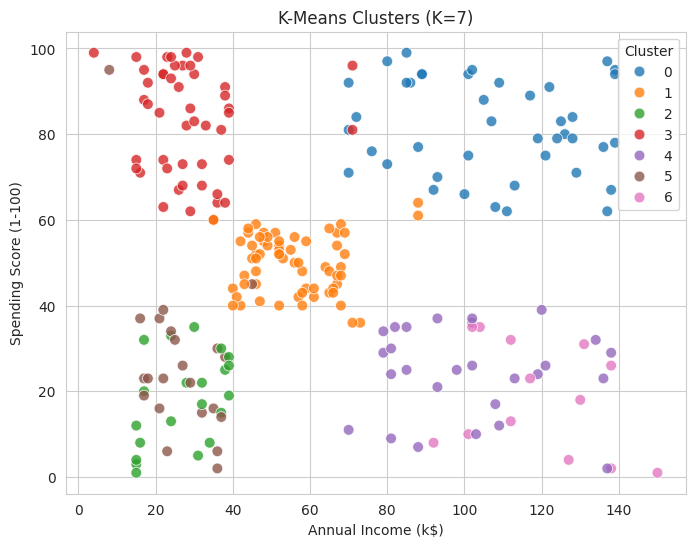

In [6]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df, x="Annual Income (k$)", y="Spending Score (1-100)",
    hue="Cluster", palette="tab10", s=60, alpha=0.8
)
plt.title(f"K-Means Clusters (K={chosen_k})")
plt.savefig("../reports/figures/03_kmeans_clusters.png", dpi=120)
plt.show()

## Assign human-readable personas

In [7]:
personas = label_personas(df, cluster_col="Cluster")
for cid, name in sorted(personas.items()):
    print(f"Cluster {cid}: {name}")

df["Persona"] = df["Cluster"].map(personas)
df.groupby("Persona")[FEATURE_COLUMNS].mean().round(1)

Cluster 0: High-Income, High-Spender (Target)
Cluster 1: High-Income, High-Spender (Target)
Cluster 2: Low-Income, Low-Spender (Careful)
Cluster 3: Low-Income, High-Spender (Impulsive)
Cluster 4: High-Income, Low-Spender (Saver)
Cluster 5: Low-Income, High-Spender (Impulsive)
Cluster 6: High-Income, Low-Spender (Saver)


,Age,Annual Income (k$),Spending Score (1-100)
Persona,,,
"High-Income, High-Spender (Target)",37.6,76.0,62.4
"High-Income, Low-Spender (Saver)",51.3,107.3,22.4
"Low-Income, High-Spender (Impulsive)",35.0,28.0,65.0
"Low-Income, Low-Spender (Careful)",36.3,27.3,18.0


## Hierarchical Clustering — Dendrogram

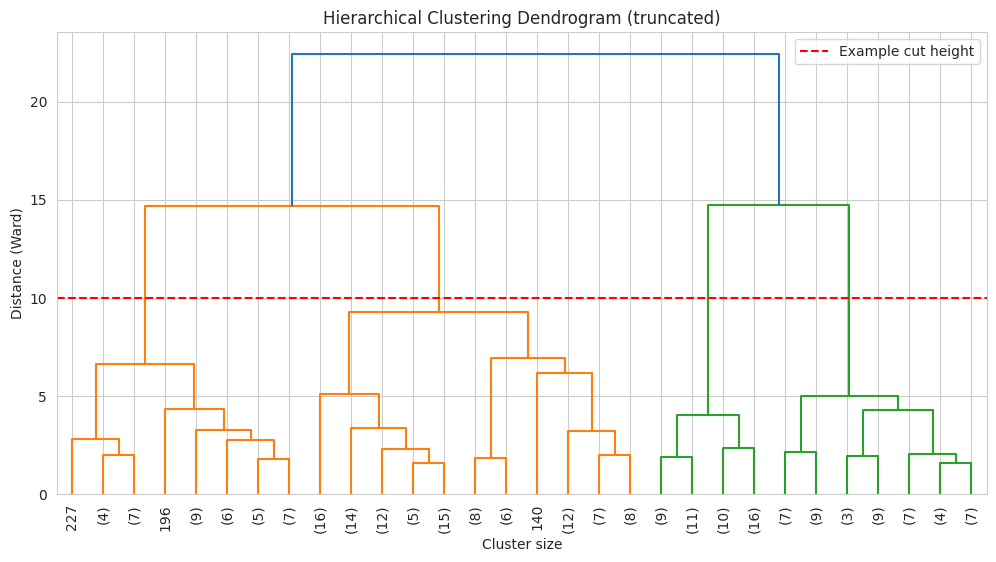

In [8]:
linked = linkage(X_scaled, method="ward")

plt.figure(figsize=(12, 6))
dendrogram(linked, truncate_mode="lastp", p=30, leaf_rotation=90)
plt.title("Hierarchical Clustering Dendrogram (truncated)")
plt.xlabel("Cluster size")
plt.ylabel("Distance (Ward)")
plt.axhline(y=10, color="red", linestyle="--", label="Example cut height")
plt.legend()
plt.savefig("../reports/figures/03_dendrogram.png", dpi=120)
plt.show()

In [9]:
hc_model, hc_labels = fit_hierarchical(X_scaled, n_clusters=chosen_k)
df["Cluster_HC"] = hc_labels

# Compare K-Means vs Hierarchical agreement
pd.crosstab(df["Cluster"], df["Cluster_HC"])

Cluster_HC,0,1,2,3,4,5,6
Cluster,,,,,,,
0,0,0,0,42,0,0,0
1,0,61,1,2,0,0,0
2,7,0,0,0,0,14,0
3,0,0,45,2,0,0,0
4,0,0,0,0,27,0,0
5,21,1,0,0,0,0,0
6,0,0,0,0,1,0,12


## Notes
- K-Means and Hierarchical should largely agree on grouping (crosstab
  above should show most mass concentrated on a near-diagonal pattern,
  even if cluster *numbering* differs between the two methods).
- We'll carry the K-Means model + persona labels forward as our
  "official" segmentation model, since it's the one we'll serve via
  FastAPI (K-Means has a clean `.predict()` for new points; DBSCAN and
  Hierarchical don't natively support predicting brand-new points the
  same way).
- Processed dataframe with Cluster + Persona saved below for the next
  notebook.

In [10]:
df.to_csv("../data/processed/mall_customers_with_clusters.csv", index=False)
joblib.dump(kmeans_model, "../models/kmeans_model.joblib")
joblib.dump(personas, "../models/persona_labels.joblib")
print("Saved kmeans_model.joblib and persona_labels.joblib")

Saved kmeans_model.joblib and persona_labels.joblib
